<a href="https://colab.research.google.com/github/5ahar-K/Project/blob/main/BER2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

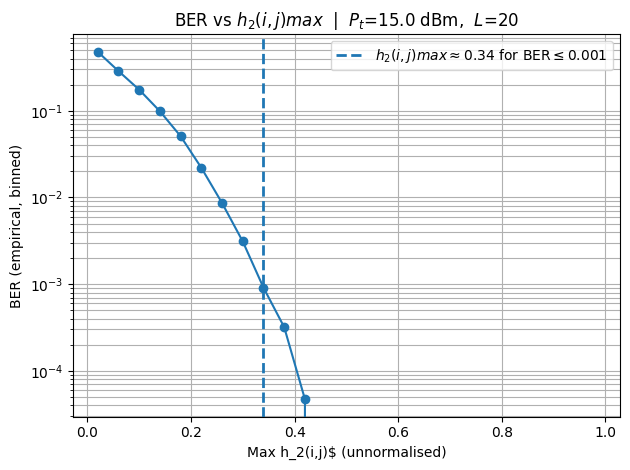

Pt = 15.00 dBm  (3.162e-02 W)
Trials used (after interruption filter=False): 200000
eta_cap range: [0, 1]
Bins with >= 50 samples: 25/25
Method 2 threshold: eta_cap_th pprox 0.34


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# ======================
# Helpers
# ======================
def Q(x):
    return 0.5 * erfc(x / np.sqrt(2.0))

def dBm_to_W(Pt_dBm: float) -> float:
    # Pt(W) = 10^((Pt_dBm - 30)/10)
    return 10 ** ((Pt_dBm - 30.0) / 10.0)

# ======================
# Unnormalised h2 map (lens -> detector)
#   - h2(i,j) is the fraction of total beam power that lands on pixel (i,j)
#   - eta_cap = sum(h2) is the captured power fraction by the whole array (<= 1)
# ======================
def compute_h2_matrix_unnormalized(theta_x, theta_y, Na, wa, wf, fc, sigma_I):
    w_prime = wa + wf
    x0 = fc * theta_x
    y0 = fc * theta_y

    i = np.arange(Na)
    j = np.arange(Na)

    x_left  = (i - 1 - Na/2) * w_prime + wf/2
    x_right = (i     - Na/2) * w_prime - wf/2
    ax1 = (x_left  - x0) / sigma_I
    ax2 = (x_right - x0) / sigma_I
    px = Q(ax1) - Q(ax2)

    y_bottom = (j - 1 - Na/2) * w_prime + wf/2
    y_top    = (j     - Na/2) * w_prime - wf/2
    ay1 = (y_bottom - y0) / sigma_I
    ay2 = (y_top    - y0) / sigma_I
    py = Q(ay1) - Q(ay2)

    # Unnormalised captured fractions per pixel
    h2 = px[:, None] * py[None, :]
    return h2

def interruption_mask(theta_x, theta_y, Na, wa, wf, fc):
    """Hard 'miss' condition based on spot center outside array radius."""
    w_prime = wa + wf
    r_array = (Na * w_prime) / 2.0
    x0 = fc * theta_x
    y0 = fc * theta_y
    r_d = np.sqrt(x0**2 + y0**2)
    return r_d > r_array

# ======================
# Generate one block of received samples
# ======================
def generate_block(Pt_W, Na, L, h2_unnorm, mu, sigma_s, sigma0, p1=0.5, rng=None):
    """
    h2_unnorm: (Na,Na) unnormalised coupling fractions
    Model matches your original:
      mean = mu * Pt * h_ij * s_k
      var  = sigma_s^2 * (Pt * h_ij * s_k) + sigma0^2
    """
    if rng is None:
        rng = np.random.default_rng()

    s = (rng.random(L) < p1).astype(float)      # OOK symbols
    R = np.zeros((Na, Na, L), dtype=float)

    for k in range(L):
        sk = s[k]
        for i in range(Na):
            for j in range(Na):
                hij = h2_unnorm[i, j]
                mean = mu * hij * sk * Pt_W
                var  = (sigma_s**2) * (Pt_W * hij * sk) + sigma0**2
                R[i, j, k] = rng.normal(mean, np.sqrt(var))

    return s, R

# ======================
# Joint detection + tracking (your original)
# ======================
def joint_detect_and_track(R, mu, max_patterns=None):
    Na, _, L = R.shape

    y = np.sum(R, axis=(0, 1))
    sorted_idx = np.argsort(-y)
    R_sorted = R[:, :, sorted_idx]

    if max_patterns is None or max_patterns > L:
        max_patterns = L

    cumsum_R = np.cumsum(R_sorted, axis=2)

    best_metric = -np.inf
    best_m = 1

    for m in range(1, max_patterns + 1):
        S1_m = cumsum_R[:, :, m-1]
        metric_m = np.sum(S1_m**2) / m
        if metric_m > best_metric:
            best_metric = metric_m
            best_m = m

    s_hat = np.zeros(L)
    s_hat[sorted_idx[:best_m]] = 1.0

    R_weighted = R * s_hat[None, None, :]
    h_hat = np.sum(R_weighted, axis=2) / (best_m * mu)

    power_hat = np.abs(h_hat)**2
    idx_hat = np.argmax(power_hat)
    i_hat, j_hat = np.unravel_index(idx_hat, (Na, Na))

    return s_hat, h_hat, i_hat, j_hat

# ======================
# One Monte Carlo trial
#   Returns BER + alignment metric on x-axis
#   For Method 2 (comms-driven), eta_cap = sum(h2) is the best x-axis.
# ======================
def one_trial_joint_return_metric(Pt_W, params, rng):
    Na      = params["Na"]
    L       = params["L"]
    wa      = params["wa"]
    wf      = params["wf"]
    fc      = params["fc"]
    sigma_I = params["sigma_I"]
    sigma_x = params["sigma_x"]
    sigma_y = params["sigma_y"]
    mu      = params["mu"]
    sigma_s = params["sigma_s"]
    sigma0  = params["sigma0"]

    theta_x = rng.normal(0.0, sigma_x)
    theta_y = rng.normal(0.0, sigma_y)

    # Hard interruption (optional model)
    if interruption_mask(theta_x, theta_y, Na, wa, wf, fc):
        # Treat as "no link": BER ~ 0.5, metric=0
        return 0.5, 0.0, 1

    h2_true = compute_h2_matrix_unnormalized(theta_x, theta_y, Na, wa, wf, fc, sigma_I)

    # Alignment/capture metric for Method 2:
    eta_cap = float(np.sum(h2_true))     # <= 1, physical captured fraction

    # Generate + run joint detector
    s_true, R = generate_block(Pt_W, Na, L, h2_true, mu, sigma_s, sigma0, rng=rng)
    s_hat, h_hat, i_hat, j_hat = joint_detect_and_track(R, mu)

    ber = float(np.mean(s_true != s_hat))

    # Tracking error (optional, not used for the BER curve)
    idx_true = int(np.argmax(np.abs(h2_true)**2))
    i_true, j_true = np.unravel_index(idx_true, (Na, Na))
    track_error = int((i_true != i_hat) or (j_true != j_hat))

    return ber, eta_cap, track_error

# ======================
# BER vs eta_cap (binned) + Method-2 threshold extraction
# ======================
def ber_vs_h2_metric_method2(
    Pt_dBm,
    params,
    n_trials=200000,
    seed=1234,
    n_bins=25,
    ber_target=1e-3,
    exclude_interrupted=True,
    min_count_per_bin=50
):
    rng = np.random.default_rng(seed)
    Pt_W = dBm_to_W(Pt_dBm)

    bers = np.empty(n_trials, dtype=float)
    mets = np.empty(n_trials, dtype=float)

    for t in range(n_trials):
        ber, metric, _ = one_trial_joint_return_metric(Pt_W, params, rng)
        bers[t] = ber
        mets[t] = metric

    if exclude_interrupted:
        mask = mets > 0.0
        bers = bers[mask]
        mets = mets[mask]

    if len(mets) == 0:
        raise RuntimeError("All trials were interrupted. Reduce jitter or increase array size/FOV.")

    # Bin metric
    edges = np.linspace(mets.min(), mets.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ber_bin = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        m = (mets >= edges[b]) & (mets < edges[b+1])
        counts[b] = int(np.sum(m))
        if counts[b] >= min_count_per_bin:
            ber_bin[b] = float(np.mean(bers[m]))

    # Threshold = first bin center where BER <= target (after skipping sparse bins)
    h2_th = None
    valid = ~np.isnan(ber_bin)
    idxs = np.where(valid & (ber_bin <= ber_target))[0]
    if len(idxs) > 0:
        h2_th = float(centers[idxs[0]])

    # Plot
    plt.figure()
    plt.semilogy(centers, ber_bin, marker="o")
    plt.grid(True, which="both")
    plt.xlabel(r"Max h_2(i,j)$ (unnormalised)")
    plt.ylabel("BER (empirical, binned)")
    plt.title(rf"BER vs $ h_2(i,j) max$  |  $P_t$={Pt_dBm:.1f} dBm,  $L$={params['L']}")
    if h2_th is not None:
        plt.axvline(h2_th, linestyle="--", linewidth=2,
                    label=rf"$h_2(i,j) max\approx {h2_th:.3g}$ for BER$\leq {ber_target}$")
        plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Pt = {Pt_dBm:.2f} dBm  ({Pt_W:.3e} W)")
    print(f"Trials used (after interruption filter={exclude_interrupted}): {len(mets)}")
    print(f"eta_cap range: [{mets.min():.4g}, {mets.max():.4g}]")
    print(f"Bins with >= {min_count_per_bin} samples: {np.sum(counts >= min_count_per_bin)}/{n_bins}")
    if h2_th is None:
        print(f"No reliable bin achieved BER <= {ber_target}. Try higher Pt, larger L, or more trials.")
    else:
        print(f"Method 2 threshold: eta_cap_th \approx {h2_th:.6g}")

    return centers, ber_bin, counts, h2_th

# ======================
# Example usage
# ======================
if __name__ == "__main__":
    params = {
        "Na": 2,
        "L": 20,
        "wa": 2e-3,
        "wf": 0.0,
        "fc": 0.05,
        "sigma_I": 100e-6,
        "sigma_x": 5e-3,
        "sigma_y": 5e-3,
        "mu": 1.0,
        "sigma_s": 0.01,
        "sigma0": 0.001
    }

    # Choose a fixed transmit power in dBm
    Pt_dBm = 15.0  # Optimised using the BER vs Pt plot

    ber_vs_h2_metric_method2(
        Pt_dBm=Pt_dBm,
        params=params,
        n_trials=200000,
        seed=1234,
        n_bins=25,
        ber_target=1e-3,
        exclude_interrupted=False,
        min_count_per_bin=50
    )

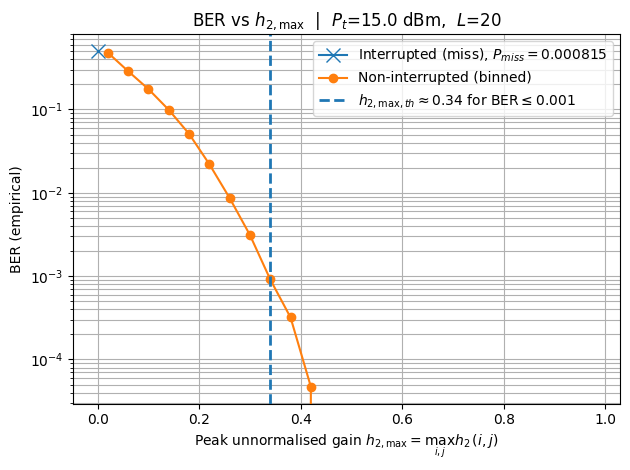

Pt = 15.00 dBm  (3.162e-02 W)
Total trials: 200000
Interruption probability P_miss ≈ 0.000815
BER when interrupted (h2_max=0): 0.506442
Nonzero h2_max range: [4.047e-27, 1]
Bins with >= 50 samples: 25/25
Method 2 threshold: h2_max_th ≈ 0.34


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# ======================
# Helpers
# ======================
def Q(x):
    return 0.5 * erfc(x / np.sqrt(2.0))

def dBm_to_W(Pt_dBm: float) -> float:
    # Pt(W) = 10^((Pt_dBm - 30)/10)
    return 10 ** ((Pt_dBm - 30.0) / 10.0)

# ======================
# Unnormalised h2 map (lens -> detector)
#   h2[i,j] = fraction of TOTAL beam power that lands on pixel (i,j)
#   sum(h2) = eta_cap <= 1 (captured power fraction by the array)
# ======================
def compute_h2_matrix_unnormalized(theta_x, theta_y, Na, wa, wf, fc, sigma_I):
    w_prime = wa + wf
    x0 = fc * theta_x
    y0 = fc * theta_y

    i = np.arange(Na)
    j = np.arange(Na)

    x_left  = (i - 1 - Na/2) * w_prime + wf/2
    x_right = (i     - Na/2) * w_prime - wf/2
    ax1 = (x_left  - x0) / sigma_I
    ax2 = (x_right - x0) / sigma_I
    px = Q(ax1) - Q(ax2)

    y_bottom = (j - 1 - Na/2) * w_prime + wf/2
    y_top    = (j     - Na/2) * w_prime - wf/2
    ay1 = (y_bottom - y0) / sigma_I
    ay2 = (y_top    - y0) / sigma_I
    py = Q(ay1) - Q(ay2)

    return px[:, None] * py[None, :]

def interruption_mask(theta_x, theta_y, Na, wa, wf, fc):
    """Hard 'miss' condition based on spot center outside array radius."""
    w_prime = wa + wf
    r_array = (Na * w_prime) / 2.0
    x0 = fc * theta_x
    y0 = fc * theta_y
    r_d = np.sqrt(x0**2 + y0**2)
    return r_d > r_array

# ======================
# Generate one block of received samples
# ======================
def generate_block(Pt_W, Na, L, h2_unnorm, mu, sigma_s, sigma0, p1=0.5, rng=None):
    """
    mean = mu * Pt * h_ij * s_k
    var  = sigma_s^2 * (Pt * h_ij * s_k) + sigma0^2
    """
    if rng is None:
        rng = np.random.default_rng()

    s = (rng.random(L) < p1).astype(float)
    R = np.zeros((Na, Na, L), dtype=float)

    for k in range(L):
        sk = s[k]
        for i in range(Na):
            for j in range(Na):
                hij = h2_unnorm[i, j]
                mean = mu * hij * sk * Pt_W
                var  = (sigma_s**2) * (Pt_W * hij * sk) + sigma0**2
                R[i, j, k] = rng.normal(mean, np.sqrt(var))

    return s, R

# ======================
# Joint detection + tracking (your original)
# ======================
def joint_detect_and_track(R, mu, max_patterns=None):
    Na, _, L = R.shape

    y = np.sum(R, axis=(0, 1))
    sorted_idx = np.argsort(-y)
    R_sorted = R[:, :, sorted_idx]

    if max_patterns is None or max_patterns > L:
        max_patterns = L

    cumsum_R = np.cumsum(R_sorted, axis=2)

    best_metric = -np.inf
    best_m = 1

    for m in range(1, max_patterns + 1):
        S1_m = cumsum_R[:, :, m-1]
        metric_m = np.sum(S1_m**2) / m
        if metric_m > best_metric:
            best_metric = metric_m
            best_m = m

    s_hat = np.zeros(L)
    s_hat[sorted_idx[:best_m]] = 1.0

    R_weighted = R * s_hat[None, None, :]
    h_hat = np.sum(R_weighted, axis=2) / (best_m * mu)

    power_hat = np.abs(h_hat)**2
    idx_hat = np.argmax(power_hat)
    i_hat, j_hat = np.unravel_index(idx_hat, (Na, Na))

    return s_hat, h_hat, i_hat, j_hat

# ======================
# One Monte Carlo trial
#   X-axis metric = max unnormalised true h2 (peak captured fraction)
#   If interrupted: metric=0, BER=0.5
# ======================
def one_trial_joint_return_metric(Pt_W, params, rng):
    Na      = params["Na"]
    L       = params["L"]
    wa      = params["wa"]
    wf      = params["wf"]
    fc      = params["fc"]
    sigma_I = params["sigma_I"]
    sigma_x = params["sigma_x"]
    sigma_y = params["sigma_y"]
    mu      = params["mu"]
    sigma_s = params["sigma_s"]
    sigma0  = params["sigma0"]
    p1      = params.get("p1", 0.5)

    theta_x = rng.normal(0.0, sigma_x)
    theta_y = rng.normal(0.0, sigma_y)

    if interruption_mask(theta_x, theta_y, Na, wa, wf, fc):
        return 0.5, 0.0, 1

    h2_true = compute_h2_matrix_unnormalized(theta_x, theta_y, Na, wa, wf, fc, sigma_I)

    # ---- X-axis metric: peak captured fraction (unnormalised)
    h2_max = float(np.max(h2_true))

    s_true, R = generate_block(Pt_W, Na, L, h2_true, mu, sigma_s, sigma0, p1=p1, rng=rng)
    s_hat, h_hat, i_hat, j_hat = joint_detect_and_track(R, mu)

    ber = float(np.mean(s_true != s_hat))

    idx_true = int(np.argmax(np.abs(h2_true)**2))
    i_true, j_true = np.unravel_index(idx_true, (Na, Na))
    track_error = int((i_true != i_hat) or (j_true != j_hat))

    return ber, h2_max, track_error

# ======================
# BER vs h2_max (binned) + threshold extraction (Method 2)
# ======================
def ber_vs_h2max_method2(
    Pt_dBm,
    params,
    n_trials=200000,
    seed=1234,
    n_bins=25,
    ber_target=1e-3,
    include_interruptions=True,
    min_count_per_bin=50
):
    rng = np.random.default_rng(seed)
    Pt_W = dBm_to_W(Pt_dBm)

    bers = np.empty(n_trials, dtype=float)
    mets = np.empty(n_trials, dtype=float)

    for t in range(n_trials):
        ber, metric, _ = one_trial_joint_return_metric(Pt_W, params, rng)
        bers[t] = ber
        mets[t] = metric

    # --- Handle interruptions explicitly (metric==0)
    is_interrupt = (mets == 0.0)
    ber_interrupt = float(np.mean(bers[is_interrupt])) if np.any(is_interrupt) else np.nan
    p_interrupt = float(np.mean(is_interrupt))

    if not include_interruptions:
        bers = bers[~is_interrupt]
        mets = mets[~is_interrupt]

    if len(mets) == 0:
        raise RuntimeError("No non-interrupted samples. Reduce jitter or increase array size/FOV.")

    # --- Bin ONLY the nonzero h2_max values to avoid smearing the mass at 0
    mets_nz = mets[mets > 0.0]
    bers_nz = bers[mets > 0.0]

    if len(mets_nz) == 0:
        raise RuntimeError("All samples are interruptions (h2_max=0). Reduce jitter or increase array size/FOV.")

    edges = np.linspace(mets_nz.min(), mets_nz.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ber_bin = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        m = (mets_nz >= edges[b]) & (mets_nz < edges[b+1])
        counts[b] = int(np.sum(m))
        if counts[b] >= min_count_per_bin:
            ber_bin[b] = float(np.mean(bers_nz[m]))

    # Threshold = first bin center where BER <= target (skipping sparse bins)
    h2_th = None
    valid = ~np.isnan(ber_bin)
    idxs = np.where(valid & (ber_bin <= ber_target))[0]
    if len(idxs) > 0:
        h2_th = float(centers[idxs[0]])

    # Plot
    plt.figure()

    if include_interruptions and np.any(is_interrupt):
        plt.semilogy([0.0], [ber_interrupt], marker="x", markersize=10,
                     label=rf"Interrupted (miss), $P_{{miss}}={p_interrupt:.3g}$")

    plt.semilogy(centers, ber_bin, marker="o", label="Non-interrupted (binned)")
    plt.grid(True, which="both")
    plt.xlabel(r"Peak unnormalised gain $h_{2,\max}=\max_{i,j} h_2(i,j)$")
    plt.ylabel("BER (empirical)")
    plt.title(rf"BER vs $h_{{2,\max}}$  |  $P_t$={Pt_dBm:.1f} dBm,  $L$={params['L']}")
    if h2_th is not None:
        plt.axvline(h2_th, linestyle="--", linewidth=2,
                    label=rf"$h_{{2,\max,th}}\approx {h2_th:.3g}$ for BER$\leq {ber_target}$")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Pt = {Pt_dBm:.2f} dBm  ({Pt_W:.3e} W)")
    print(f"Total trials: {n_trials}")
    print(f"Interruption probability P_miss ≈ {p_interrupt:.6g}")
    if np.any(is_interrupt):
        print(f"BER when interrupted (h2_max=0): {ber_interrupt:.6g}")
    print(f"Nonzero h2_max range: [{mets_nz.min():.4g}, {mets_nz.max():.4g}]")
    print(f"Bins with >= {min_count_per_bin} samples: {np.sum(counts >= min_count_per_bin)}/{n_bins}")
    if h2_th is None:
        print(f"No reliable bin achieved BER <= {ber_target}. Try higher Pt, larger L, or more trials.")
    else:
        print(f"Method 2 threshold: h2_max_th ≈ {h2_th:.6g}")

    return centers, ber_bin, counts, h2_th

# ======================
# Example usage
# ======================
if __name__ == "__main__":
    params = {
        "Na": 2,
        "L": 20,
        "wa": 2e-3,
        "wf": 0.0,
        "fc": 0.05,
        "sigma_I": 100e-6,
        "sigma_x": 5e-3,
        "sigma_y": 5e-3,
        "mu": 1.0,
        "sigma_s": 0.01,
        "sigma0": 0.001,
        "p1": 0.5
    }

    # Choose a fixed transmit power in dBm
    Pt_dBm = 15.0

    ber_vs_h2max_method2(
        Pt_dBm=Pt_dBm,
        params=params,
        n_trials=200000,
        seed=1234,
        n_bins=25,
        ber_target=1e-3,
        include_interruptions=True,
        min_count_per_bin=50
    )
